In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

all_dfs = []

# Parameters
E=1
rho=2
L=1

Nt=300
Nx=100
SS=4

Ntot = Nx + 2*SS

i_left = SS
i_right = Ntot - SS
nodes = np.arange(i_left, i_right)  

t_end=3
dt=t_end/Nt
dx = L / (Nx - 1)
CFL = dt/dx * np.sqrt(E/rho)

ndt = 1

N=6
LAG_LABELS = {0: "t", 1: "t-dt", 2: "t-2dt"}

def jlabel(k):
    return "j" if k == 0 else f"j{k:+d}"

AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(1, 10, N).round(1).tolist()
n_sims = len(AMPLITUDES)*len(PULSATIONS)

# We compute each simulation
all_dfs = []

for idx, (A, omega) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):

    t_pulse = 2 * np.pi / omega
    def u_right(t):
        return A * np.sin(omega * t) if t < t_pulse else 0.0

    u    = np.zeros(Ntot)
    u_1  = np.zeros(Ntot)
    u_xx = np.zeros(Ntot)

    u_storage    = np.zeros((Nt + 1, Ntot))
    u_xx_storage = np.zeros((Nt,     Ntot))
    u_storage[0] = u.copy()

    i_left  = SS
    i_right = Ntot - SS

    # --- Boucle de simulation sur la grille étendue ---
    for n in range(Nt):

        t = n * dt

        u_xx[i_left:i_right+1] = (u[i_left-1:i_right] - 2*u[i_left:i_right+1] + u[i_left+1:i_right+2]) / dx**2

        u_new = np.zeros(Ntot)

        u_new[i_left:i_right+1] = (2.0 * u[i_left:i_right+1] - u_1[i_left:i_right+1] + CFL**2 * (u[i_left-1:i_right] - 2.0 * u[i_left:i_right+1] + u[i_left+1:i_right+2]))

        u_new[:i_left+1] = 0.0     
        u_new[i_right:]  = u_right(t + dt) 

        u_xx_storage[n] = u_xx
        
        u_1 = u.copy()
        
        u   = u_new
        
        u_storage[n + 1] = u.copy()

    rows = []
    
    for n in range(3*ndt, Nt - ndt + 1):
        row = {"A": A, "omega": omega, "n_step": n}

        for lvl in (0, 1, 2):    

            m    = n - lvl * ndt                            
            tlab = LAG_LABELS[lvl]
            udot_m = (u_storage[m] - u_storage[m - ndt]) / (ndt * dt) 

            for k in range(-SS, SS + 1):                     
                row[f"u_dot({tlab},{jlabel(k)})"] = udot_m[nodes + k]
                row[f"u_xx({tlab},{jlabel(k)})"]  = u_xx_storage[m, nodes + k]

        row["delta_u@ndt"] = u_storage[n + ndt, nodes] - u_storage[n, nodes]

        rows.append(pd.DataFrame(row))

    all_dfs.append(pd.concat(rows, ignore_index=True))

df = pd.concat(all_dfs, ignore_index=True)
print(df.head(0))
print(f"{len(df):,} lignes × {df.shape[1]} colonnes")


Empty DataFrame
Columns: [A, omega, n_step, u_dot(t,j-5), u_xx(t,j-5), u_dot(t,j-4), u_xx(t,j-4), u_dot(t,j-3), u_xx(t,j-3), u_dot(t,j-2), u_xx(t,j-2), u_dot(t,j-1), u_xx(t,j-1), u_dot(t,j), u_xx(t,j), u_dot(t,j+1), u_xx(t,j+1), u_dot(t,j+2), u_xx(t,j+2), u_dot(t,j+3), u_xx(t,j+3), u_dot(t,j+4), u_xx(t,j+4), u_dot(t,j+5), u_xx(t,j+5), u_dot(t-dt,j-5), u_xx(t-dt,j-5), u_dot(t-dt,j-4), u_xx(t-dt,j-4), u_dot(t-dt,j-3), u_xx(t-dt,j-3), u_dot(t-dt,j-2), u_xx(t-dt,j-2), u_dot(t-dt,j-1), u_xx(t-dt,j-1), u_dot(t-dt,j), u_xx(t-dt,j), u_dot(t-dt,j+1), u_xx(t-dt,j+1), u_dot(t-dt,j+2), u_xx(t-dt,j+2), u_dot(t-dt,j+3), u_xx(t-dt,j+3), u_dot(t-dt,j+4), u_xx(t-dt,j+4), u_dot(t-dt,j+5), u_xx(t-dt,j+5), u_dot(t-2dt,j-5), u_xx(t-2dt,j-5), u_dot(t-2dt,j-4), u_xx(t-2dt,j-4), u_dot(t-2dt,j-3), u_xx(t-2dt,j-3), u_dot(t-2dt,j-2), u_xx(t-2dt,j-2), u_dot(t-2dt,j-1), u_xx(t-2dt,j-1), u_dot(t-2dt,j), u_xx(t-2dt,j), u_dot(t-2dt,j+1), u_xx(t-2dt,j+1), u_dot(t-2dt,j+2), u_xx(t-2dt,j+2), u_dot(t-2dt,j+3), u_xx(t-2dt

## Split train and val 

In [3]:
rng = np.random.default_rng(seed=42)

n_rows = len(df)
n_train = int(0.60 * n_rows)
n_val   = int(0.20 * n_rows)
n_test  = n_rows - n_train - n_val

# 1. On crée un grand tableau contenant la proportion exacte de chaque étiquette
split_labels = np.array(["train"] * n_train + ["val"] * n_val + ["test"] * n_test)

# 2. On le mélange de manière purement aléatoire
rng.shuffle(split_labels)

# 3. On l'assigne directement à la colonne du DataFrame
df["split"] = split_labels

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")

Distribution du split :
  train :  641,520 lignes  (60.0 %)
  val   :  213,840 lignes  (20.0 %)
  test  :  213,840 lignes  (20.0 %)


In [4]:
# Les colonnes qui ne sont PAS des features d'entrée
a_exclure = ["A", "omega", "n_step", "delta_u@ndt", "split"]

INPUTS = [c for c in df.columns if c not in a_exclure]
OUTPUTS = ["delta_u@ndt"]

# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "E": E,
    "rho":rho,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
    "INPUTS":INPUTS,
    "OUTPUTS":OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")



Statistiques de normalisation (calculées sur train) :
                      mean       std
u_dot(t,j-5)     -0.000771  0.188224
u_xx(t,j-5)       0.029768  7.241851
u_dot(t,j-4)     -0.000820  0.188885
u_xx(t,j-4)       0.022220  7.230311
u_dot(t,j-3)     -0.000879  0.189520
...                    ...       ...
u_dot(t-2dt,j+4) -0.001186  0.192290
u_xx(t-2dt,j+4)  -0.001907  6.592629
u_dot(t-2dt,j+5) -0.001117  0.192281
u_xx(t-2dt,j+5)  -0.001993  6.546680
delta_u@ndt      -0.000007  0.001920

[67 rows x 2 columns]
Dataset sauvegardé : wave_beam_dataset.csv
  1,069,200 lignes × 135 colonnes
Stats de normalisation sauvegardées : norm_stats.csv
Paramètres sauvegardés : params_simulation.json


In [5]:
import numpy as np
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]
AMPLITUDES    = p["AMPLITUDES"]
PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]
E   = p["E"]
rho = p["rho"]
v   = np.sqrt(E / rho)
INPUTS=p["INPUTS"]
OUTPUTS=p["OUTPUTS"]

# Fichiers produits par le notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Architecture du réseau
HIDDEN_SIZES = [256, 128, 64]   

# Entraînement
LEARNING_RATE = 1e-3
N_EPOCHS      = 50
BATCH_SIZE    = 512



In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Chargement du dataset et des stats de normalisation
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} lignes")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Colonnes normalisées
INPUTS_N = [f"{x}_n" for x in INPUTS]
OUTPUTS_N = [f"{x}_n" for x in OUTPUTS]

# Extraction train / val / test en utilisant la colonne split du dataset
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"
test_mask  = df["split"] == "test"

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

X_test  = df.loc[test_mask, INPUTS_N].values.astype(np.float32)  
y_test  = df.loc[test_mask, OUTPUTS_N].values.astype(np.float32)  

print(f"\nTrain : {len(X_train):,} exemples")
print(f"Val   : {len(X_val):,} exemples")
print(f"Test  : {len(X_test):,} exemples")  

# Conversion en tenseurs PyTorch et création des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)
test_loader = DataLoader(  
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=BATCH_SIZE, shuffle=False
)

Dataset : 1,069,200 lignes
Splits  : {'train': 641520, 'val': 213840, 'test': 213840}

Train : 641,520 exemples
Val   : 213,840 exemples
Test  : 213,840 exemples


In [7]:
class Reseau(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_sizes):
        super().__init__()

        couches = []
        taille_entree = n_inputs

        for taille in hidden_sizes:
            couches.append(nn.Linear(taille_entree, taille))  # couche linéaire
            couches.append(nn.Tanh())                              # activation non-linéaire
            taille_entree = taille

        couches.append(nn.Linear(taille_entree, n_outputs))  # couche de sortie
        self.reseau = nn.Sequential(*couches)

    def forward(self, x):
        return self.reseau(x)


modele = Reseau(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_sizes = HIDDEN_SIZES,
)

n_params = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nNombre de paramètres : {n_params:,}")



Reseau(
  (reseau): Sequential(
    (0): Linear(in_features=66, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Nombre de paramètres : 58,369


Epoch    2/50  —  train: 0.0022  |  val: 0.0020  
Epoch    4/50  —  train: 0.0015  |  val: 0.0010  
Epoch    6/50  —  train: 0.0013  |  val: 0.0008  
Epoch    8/50  —  train: 0.0011  |  val: 0.0017  
Epoch   10/50  —  train: 0.0010  |  val: 0.0013  
Epoch   12/50  —  train: 0.0014  |  val: 0.0004  
Epoch   14/50  —  train: 0.0011  |  val: 0.0005  
Epoch   16/50  —  train: 0.0015  |  val: 0.0008  
Epoch   18/50  —  train: 0.0011  |  val: 0.0007  
Epoch   20/50  —  train: 0.0010  |  val: 0.0006  
Epoch   22/50  —  train: 0.0012  |  val: 0.0005  
Epoch   24/50  —  train: 0.0002  |  val: 0.0002  
Epoch   26/50  —  train: 0.0002  |  val: 0.0002  
Epoch   28/50  —  train: 0.0003  |  val: 0.0003  
Epoch   30/50  —  train: 0.0003  |  val: 0.0001  
Epoch   32/50  —  train: 0.0003  |  val: 0.0004  
Epoch   34/50  —  train: 0.0003  |  val: 0.0006  
Epoch   36/50  —  train: 0.0003  |  val: 0.0017  
Epoch   38/50  —  train: 0.0003  |  val: 0.0004  
Epoch   40/50  —  train: 0.0004  |  val: 0.0001  


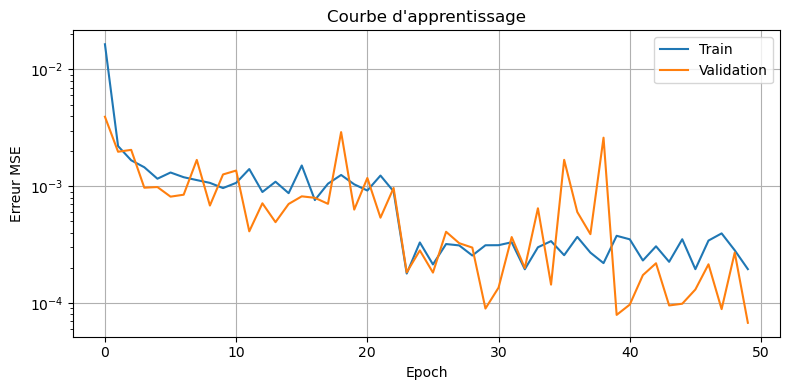

Meilleur modèle rechargé — val minimale : 0.000068


In [8]:
criterion  = nn.MSELoss() 

optimiseur = torch.optim.Adam(modele.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode="min", factor=0.5, patience=10
)

historique_train = []
historique_val   = []

meilleure_val = float("inf")   # on initialise au pire score possible
patience_compteur = 0          # on verra ça après

for epoch in range(1, N_EPOCHS + 1):

    # Phase entraînement
    modele.train()
    perte_train = 0.0       #initialisation of training loss
    for X_batch, y_batch in train_loader:
        
        optimiseur.zero_grad()                       # remet les gradients à zéro

        prediction = modele(X_batch)                 # prédiction

        perte      = criterion(prediction, y_batch)  # erreur

        perte.backward()                             # rétropropagation

        optimiseur.step()                            # mise à jour des poids
        
        perte_train += perte.item()
    perte_train /= len(train_loader)

    # Phase validation : un seul forward pass sur tout le val
    modele.eval()
    with torch.no_grad():
        pred_val = modele(torch.tensor(X_val)).numpy()

    # Loss globale 
    perte_val = ((pred_val - y_val)**2).mean()
    scheduler.step(perte_val)

    # Loss par output
    historique_train.append(perte_train)
    historique_val  .append(perte_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  —  "
            f"train: {perte_train:.4f}  |  "
            f"val: {perte_val:.4f}  ")
    
    # Si la val s'est améliorée, on sauvegarde ce modèle
    if perte_val < meilleure_val:
        meilleure_val = perte_val
        torch.save(modele.state_dict(), "model.pth")   # on écrase avec le meilleur

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historique_train, label="Train")
ax.plot(historique_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("Erreur MSE")
ax.set_title("Courbe d'apprentissage")
ax.set_yscale("log")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# On recharge le meilleur modèle trouvé pendant l'entraînement
modele.load_state_dict(torch.load("model.pth",weights_only=True ))
print(f"Meilleur modèle rechargé — val minimale : {meilleure_val:.6f}")



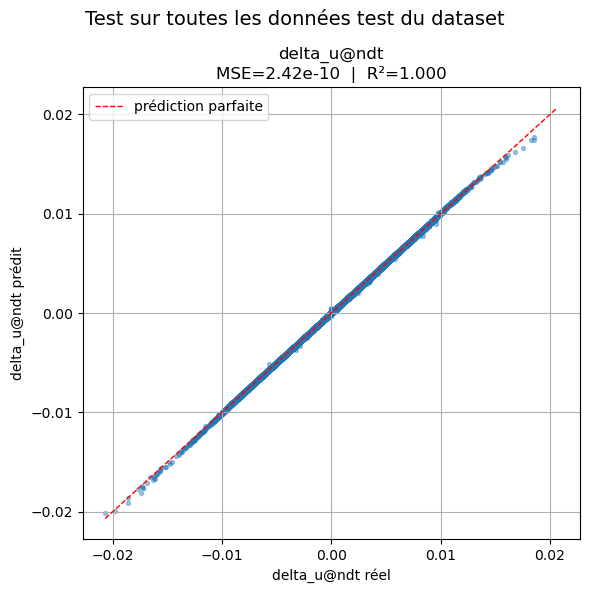

delta_u@ndt     : MSE = 2.4168e-10  |  R² = 0.9999


In [9]:
# --- 1. Choisir des paramètres ---
df_test=df[df["split"]=="test"].reset_index(drop=True)

X_new  = df_test[[c + "_n" for c in INPUTS]].values.astype(np.float32)
y_true = df_test[OUTPUTS].values   # shape (N, 3)

# --- 4. Prédiction ---
modele.eval()
with torch.no_grad():
    y_pred_n = modele(torch.tensor(X_new)).numpy()   # shape (N, 3)

# Dénormalisation colonne par colonne
y_pred = np.zeros_like(y_pred_n)
for i, col in enumerate(OUTPUTS):
    mean_du = norm_stats.loc[col, "mean"]
    std_du  = norm_stats.loc[col, "std"]
    y_pred[:, i] = y_pred_n[:, i] * std_du + mean_du

# --- 5. Visualisation : une figure par sortie ---
fig, axes = plt.subplots(1, len(OUTPUTS), figsize=(6*len(OUTPUTS), 6), squeeze=False)
axes = axes.flatten()

#fig, axes = plt.subplots(1, len(OUTPUTS), figsize=(6*len(OUTPUTS), 6))

for i, (ax, col) in enumerate(zip(axes, OUTPUTS)):
    y_r = y_true[:, i]
    y_p = y_pred[:, i]
    
    ax.scatter(y_r, y_p, alpha=0.4, s=8)
    lim = max(abs(y_r).max(), abs(y_p).max())
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="prédiction parfaite")
    
    ax.set_xlabel(f"{col} réel")
    ax.set_ylabel(f"{col} prédit")
    
    mse = ((y_p - y_r)**2).mean()
    r2  = 1 - mse / y_r.var()
    ax.set_title(f"{col}\nMSE={mse:.2e}  |  R²={r2:.3f}")
    ax.legend()
    ax.grid(True)

fig.suptitle("Test sur toutes les données test du dataset", fontsize=14)
plt.tight_layout()
plt.show()

# --- 6. Métriques globales ---
for i, col in enumerate(OUTPUTS):
    mse = ((y_pred[:,i] - y_true[:,i])**2).mean()
    r2  = 1 - mse / y_true[:,i].var()
    print(f"{col:15s} : MSE = {mse:.4e}  |  R² = {r2:.4f}")

5 105
100


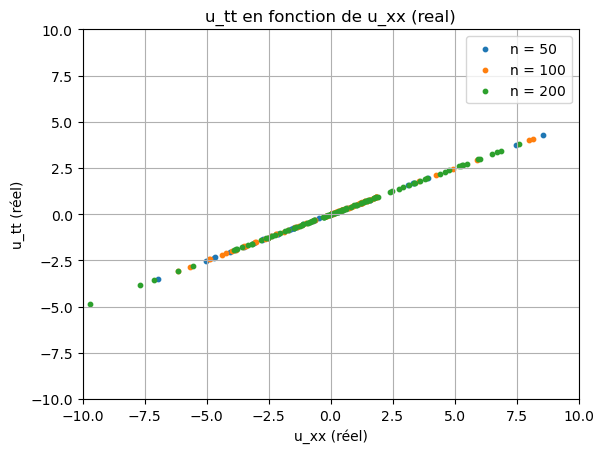

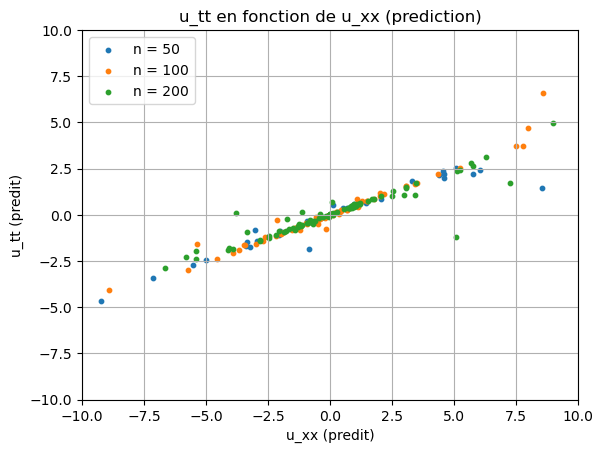

bord droit reel  : [-0.0072921 -0.0072921 -0.0072921 -0.0072921 -0.0072921]
bord droit predit: [-0.0072921 -0.0072921 -0.0072921 -0.0072921 -0.0072921]
interieur reel   : [ 0.00397341  0.0011469  -0.00167326 -0.00449462]
interieur predit : [0.01859233 0.02040951 0.02143165 0.0219803 ]


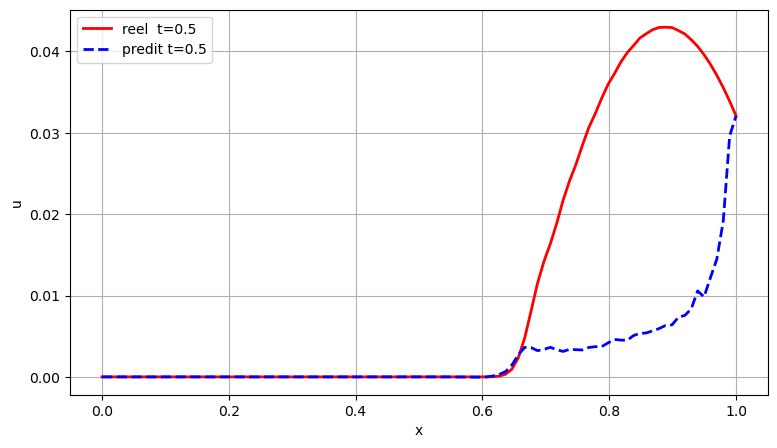

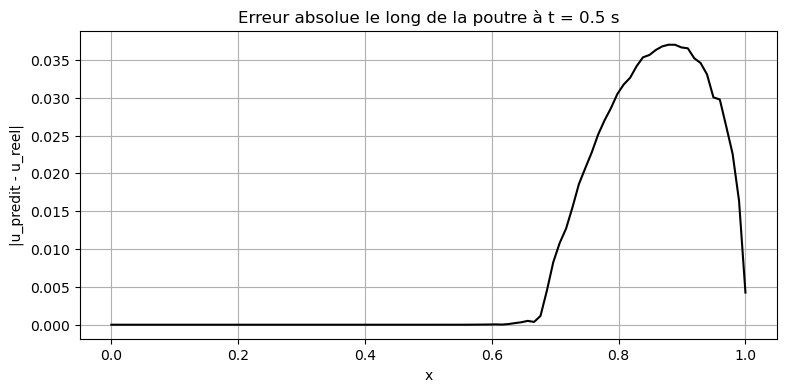

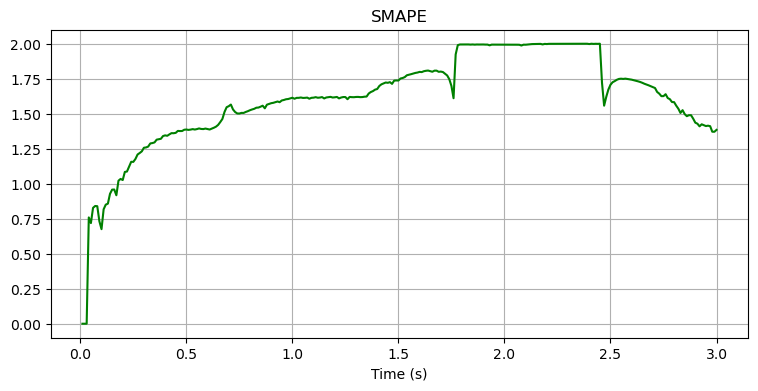

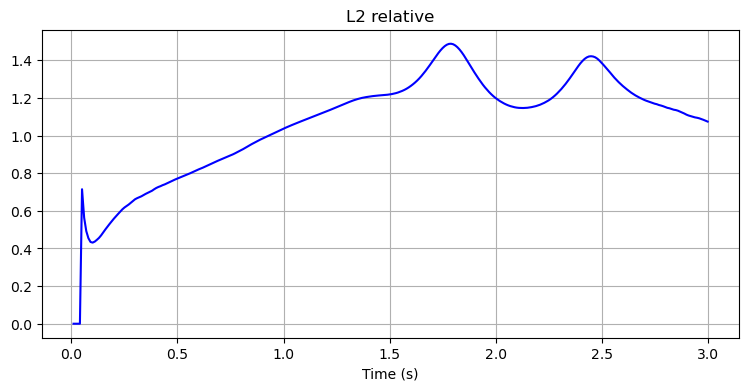

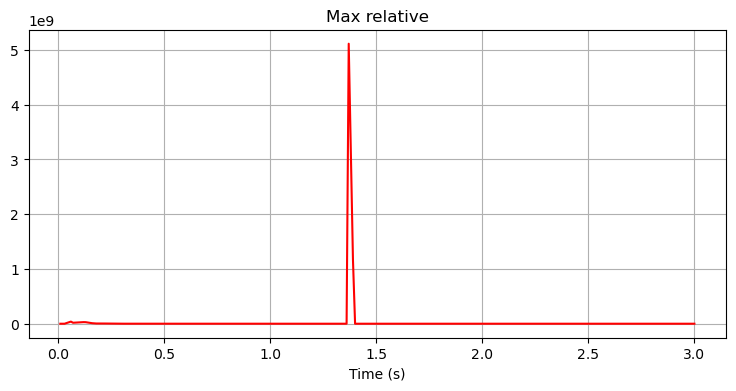

In [ ]:
# Roll out cell  (avance par paquets de 1 pas)
import time

A, omega = AMPLITUDES[2], PULSATIONS[2]
dx = L / (Nx - 1)
dt = t_end / Nt
CFL = v * dt / dx
x = np.linspace(0, L, Nx)
t_list = [0.5]

t_pulse = 2 * np.pi / omega

def u_right(t):
    if t < t_pulse:
        return A * np.sin(omega * t)
    else:
        return 0.0

def u_xx_de(uu):
    out = np.zeros(Nx)
    out[1:-1] = (uu[2:] - 2*uu[1:-1] + uu[:-2]) / dx**2
    return out

def shift_clamp(a, dk):                
    idx = np.clip(np.arange(Nx) + dk, 0, Nx - 1)
    return a[idx]

# Décodage automatique des noms de colonnes : "u_xx(t-dt,j+1)" -> ("u_xx", 1, +1)
def parse_feature(name):
    field, rest = name.replace("@", "").split("(")
    time_lab, space_lab = rest.rstrip(")").split(",")
    k = {"t": 0, "t-dt": 1, "t-2dt": 2}[time_lab]

    # space_lab vaut "j", "j-3", "j+5", ...
    if space_lab == "j":
        off = 0
    else:
        off = int(space_lab[1:])   # on enlève le "j" et on convertit le reste en nombre

    return field, k, off

SPEC  = [parse_feature(c) for c in INPUTS]  

i_left, i_right = SS, Ntot - SS
print(i_left, i_right)
print(len(x))
nodes = np.arange(i_left, i_right) 
mu = norm_stats.loc[OUTPUTS, "mean"].values    
sd = norm_stats.loc[OUTPUTS, "std"].values   

def u_xx_etendu(u):                
    u_xx = np.zeros(Ntot)
    u_xx[i_left:i_right+1] = (u[i_left-1:i_right] - 2*u[i_left:i_right+1] + u[i_left+1:i_right+2]) / dx**2
    return u_xx

# =====================================================
# 1) VRAIE simulation
# =====================================================

t0 = time.perf_counter()

U_reel = np.zeros((Nt + 1, Ntot))
u, u_1 = np.zeros(Ntot), np.zeros(Ntot)
ureel_tt_dict = np.zeros((Nt, Ntot))
ureel_xx_dict = np.zeros((Nt, Ntot))

for n in range(Nt):
    t = n * dt
    u_new = np.zeros(Ntot)
    u_new[i_left:i_right+1] = (2*u[i_left:i_right+1] - u_1[i_left:i_right+1] + CFL**2 * (u[i_left-1:i_right] - 2*u[i_left:i_right+1] + u[i_left+1:i_right+2]))
    u_new[:i_left+1] = 0.0
    u_new[i_right:]  = u_right(t + dt)

    ureel_tt_dict[n, i_left:i_right+1] = (u_new[i_left:i_right+1] - 2*u[i_left:i_right+1] + u_1[i_left:i_right+1]) / dt**2
    ureel_xx_dict[n, i_left:i_right+1] = (u[i_left-1:i_right] - 2*u[i_left:i_right+1] + u[i_left+1:i_right+2] ) / dx**2

    u_1, u = u.copy(), u_new
    U_reel[n + 1] = u.copy()

# Verification of wave equation with graph 

instants = [50, 100, 200]

plt.figure()
for n in instants:
    xx_vals = ureel_xx_dict[n, i_left+1:i_right]  
    tt_vals = ureel_tt_dict[n, i_left+1:i_right] 
    plt.scatter(xx_vals, tt_vals, s=10, label=f"n = {n}")

plt.xlabel("u_xx (réel)")
plt.ylabel("u_tt (réel)")
plt.legend()
plt.grid()
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.title("u_tt en fonction de u_xx (real)")
plt.show()
    
time_phys = time.perf_counter() - t0

# =====================================================
# 2) Simulation PREDITE
# =====================================================

t0 = time.perf_counter()

history_needed = 3 * ndt

# Biais au repos (état nul) : principe inchangé
Xz = np.zeros((len(nodes), len(INPUTS)), dtype=np.float32)
for i, (name, (field, k, off)) in enumerate(zip(INPUTS, SPEC)):
    Xz[:, i] = (np.zeros(len(nodes)) - norm_stats.loc[name, "mean"]) / norm_stats.loc[name, "std"]

with torch.no_grad():
    biais_repos = (modele(torch.tensor(Xz)).numpy() * sd + mu)[0, 0]

U = np.zeros((Nt + 1 + history_needed, Ntot))

u_tt_dict = {}
u_xx_dict = {}

uxx_0 = np.zeros(Ntot)
uxx_1 = np.zeros(Ntot)
uxx_2 = np.zeros(Ntot)

for m in range(history_needed + 1):
    U[m] = U_reel[m]

for n in range(history_needed, Nt + history_needed - ndt + 1, ndt) :

    t = n * dt
    t_suivant = round((n+ndt)*dt, 5)

    udot_0 = (U[n]  - U[n - ndt]) / (ndt*dt)
    udot_1 = (U[n   - 1*ndt]    - U[n - 2*ndt])  / (ndt*dt)
    udot_2 = (U[n   - 2*ndt]    - U[n - 3*ndt])  / (ndt*dt)

    udot = [udot_0, udot_1, udot_2]

    uxx_0 = u_xx_etendu(U[n])
    uxx_1 = u_xx_etendu(U[n - 1*ndt])
    uxx_2 = u_xx_etendu(U[n - 2*ndt])
    
    uxx = [uxx_0, uxx_1, uxx_2]

    X = np.zeros((len(nodes), len(INPUTS)), dtype=np.float32)

    # Une colonne par feature, une ligne par node spatial.
    for i in range(len(INPUTS)):

        name = INPUTS[i]          
        field, k, off = SPEC[i]  

        # 1) On choisit le bon tableau : u_dot ou u_xx, à l'instant k (0=t, 1=t-dt, 2=t-2dt)
        if field == "u_dot":
            tableau = udot[k]
        else:
            tableau = uxx[k]

        # 2) Moyenne et écart-type de CETTE feature, pour la normalisation
        moyenne = norm_stats.loc[name, "mean"]
        ecart   = norm_stats.loc[name, "std"]

        # 3) On remplit la colonne i, node par node
        for ligne in range(len(nodes)):
            j = nodes[ligne]           
            valeur = tableau[j + off] 
            X[ligne, i] = (valeur - moyenne) / ecart

    with torch.no_grad():
        sortie = modele(torch.tensor(X)).numpy()
    deltas = sortie * sd + mu - biais_repos

    U[n + ndt, nodes]     = U[n, nodes] + deltas[:, 0]

    U[n + ndt , :i_left+1]    = 0.0            
    U[n + ndt , i_right:]     = u_right((n + ndt - history_needed) * dt)


time_pred = time.perf_counter() - t0

upred_tt_dict = np.zeros((Nt, Ntot))
upred_xx_dict = np.zeros((Nt, Ntot))

for n in range(1, Nt):                       
    u_prev = U[n - 1 + history_needed]      
    u_curr = U[n     + history_needed]      
    u_next = U[n + 1 + history_needed]      

    upred_tt_dict[n, i_left:i_right+1] = (u_next[i_left:i_right+1] - 2*u_curr[i_left:i_right+1] + u_prev[i_left:i_right+1]) / dt**2
    upred_xx_dict[n, i_left:i_right+1] = (u_curr[i_left-1:i_right] - 2*u_curr[i_left:i_right+1] + u_curr[i_left+1:i_right+2]) / dx**2

instants = [50, 100, 200]

plt.figure()
for n in instants:
    xx_vals = upred_xx_dict[n, i_left+1:i_right]
    tt_vals = upred_tt_dict[n, i_left+1:i_right]
    plt.scatter(xx_vals, tt_vals, s=10, label=f"n = {n}")

plt.xlabel("u_xx (predit)")
plt.ylabel("u_tt (predit)")
plt.grid()
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.legend()
plt.title("u_tt en fonction de u_xx (prediction)")
plt.show()

#print("temps physique :", round(time_phys, 6))
#print("temps predit   :", round(time_pred, 6))

m =  72 # multiple de ndt, dans la zone ou tu vois l'ecart
print("bord droit reel  :", U_reel[m, i_right:])
print("bord droit predit:", U[m + history_needed, i_right:])
print("interieur reel   :", U_reel[m, i_right-4:i_right])
print("interieur predit :", U[m + history_needed, i_right-4:i_right])

# =====================================================
# 3) Erreurs
# =====================================================

def l2_rel(pred, true, eps=1e-12):
    return np.linalg.norm(pred - true) / (np.linalg.norm(true) + eps)

def smape(pred, true):
    m = true != 0
    return np.mean(2*np.abs(true[m] - pred[m]) / (np.abs(true[m]) + np.abs(pred[m])))

def errormax(true, pred, eps=1e-12):
    return np.max(np.abs(true - pred) / (np.abs(true) + eps))

steps = np.arange(2*ndt, Nt + 1, ndt)

temps_sim    = np.array([(m + 1) * dt for m in range(Nt)])
error_mape   = np.array([smape   (U[m+1], U_reel[m+1]) for m in range(Nt)])
error_l2_rel = np.array([l2_rel  (U[m], U_reel[m]) for m in range(Nt)])
error_max    = np.array([errormax(U_reel[m+1], U[m+1]) for m in range(Nt)])


# =====================================================
# 4) Traces
# =====================================================

reel = {round(m*dt, 5): U_reel[m] for m in range(Nt + 1)}
pred = {round(m*dt, 5): U[m + history_needed] for m in range(Nt + 1)}


plt.figure(figsize=(9, 5))
for t in t_list:
    m = min(reel, key=lambda key: abs(key - t))
    plt.plot(x, reel[m][i_left+1 : i_right+1], "r",  lw=2, label=f"reel  t={t}")
    plt.plot(x, pred[m][i_left+1 : i_right+1], "b--", lw=2, label=f"predit t={t}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)

# Vérification error along the beam
t_choisi = t_list[0]
m = round(t_choisi / dt)
m = max(0, min(m, Nt)) 
u_reel = U_reel[m]
u_pred = U[m + history_needed]
erreur = np.abs(u_pred - u_reel)
erreur_poutre = erreur[i_left:i_right]
plt.figure(figsize=(9, 4))
plt.plot(x, erreur_poutre, "k", lw=1.5)
plt.xlabel("x")
plt.ylabel("|u_predit - u_reel|")
plt.title(f"Erreur absolue le long de la poutre à t = {round(m*dt, 5)} s")
plt.grid(True)
plt.show()

for err, lab, c in [(error_mape, "SMAPE", "green"), (error_l2_rel, "L2 relative", "blue"),(error_max, "Max relative", "red")]:
    plt.figure(figsize=(9, 4))
    plt.plot(temps_sim, err, color=c, lw=1.5)
    plt.xlabel("Time (s)"); plt.title(lab); plt.grid(True)


plt.show()

